Processing snapshot 1700...
Processing snapshot 1735...
Processing snapshot 1770...
Successfully saved overlapped plot: overlap_fmeltmean_1700_to_1770.png


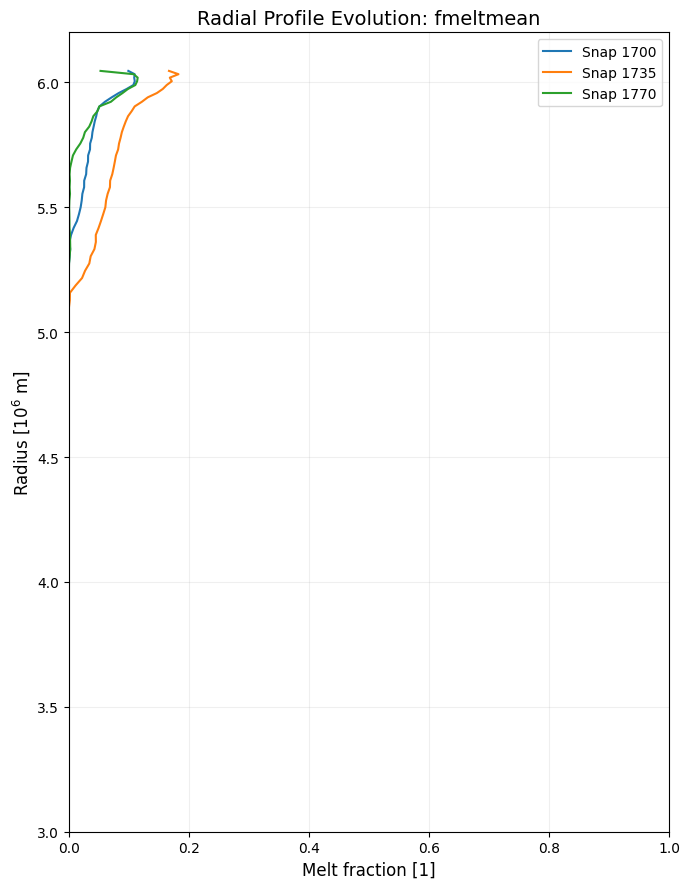

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
from stagpy.stagyydata import StagyyData

# --- FULL LIST OF RPROF PARAMETERS ---
# Use these strings in 'field_to_plot' to change the data being visualized.
ALL_RPROF_FIELDS = [
    "r",            # Radial coordinate
    "Tmean",        # Temperature
    "Tmin",         # Min temperature
    "Tmax",         # Max temperature
    "vrms",         # rms velocity
    "vmin",         # Min velocity
    "vmax",         # Max velocity
    "vzabs",        # Radial velocity
    "vzmin",        # Min radial velocity
    "vzmax",        # Max radial velocity
    "vhrms",        # Horizontal velocity
    "vhmin",        # Min horiz velocity
    "vhmax",        # Max horiz velocity
    "etalog",       # Viscosity
    "etamin",       # Min viscosity
    "etamax",       # Max viscosity
    "elog",         # Strain rate
    "emin",         # Min strain rate
    "emax",         # Max strain rate
    "slog",         # Stress
    "smin",         # Min stress
    "smax",         # Max stress
    "whrms",        # Horizontal vorticity
    "whmin",        # Min horiz vorticity
    "whmax",        # Max horiz vorticity
    "wzrms",        # Radial vorticity
    "wzmin",        # Min radial vorticity
    "wzmax",        # Max radial vorticity
    "drms",         # Divergence
    "dmin",         # Min divergence
    "dmax",         # Max divergence
    "enadv",        # Advection
    "endiff",       # Diffusion
    "enradh",       # Radiogenic heating
    "enviscdiss",   # Viscous dissipation
    "enadiabh",     # Adiabatic heating
    "bsmean",       # Basalt content
    "bsmin",        # Min basalt content
    "bsmax",        # Max basalt content
    "rhomean",      # Density
    "rhomin",       # Min density
    "rhomax",       # Max density
    "airmean",      # Air
    "airmin",       # Min air
    "airmax",       # Max air
    "primmean",     # Primordial
    "primmin",      # Min primordial
    "primmax",      # Max primordial
    "ccmean",       # Continental crust
    "ccmin",        # Min continental crust
    "ccmax",        # Max continental crust
    "fmeltmean",    # Melt fraction
    "fmeltmin",     # Min melt fraction
    "fmeltmax",     # Max melt fraction
    "metalmean",    # Metal
    "metalmin",     # Min metal
    "metalmax",     # Max metal
    "gsmean",       # Grain size
    "gsmin",        # Min grain size
    "gsmax",        # Max grain
    "viscdisslog",  # Viscous dissipation
    "viscdissmin",  # Min visc dissipation
    "viscdissmax",  # Max visc dissipation
    "advtot",       # Advection
    "advdesc",      # Downward advection
    "advasc",       # Upward advection
    "tcondmean",    # Conductivity
    "tcondmin",     # Min conductivity
    "tcondmax",     # Max conductivity
    "impmean",      # Impactor fraction
    "impmin",       # Min impactor fraction
    "impmax",       # Max impactor fraction
    "hzmean",       # Harzburgite fraction
    "hzmin",        # Min harzburgite fraction
    "hzmax",        # Max harzburgite fraction
    "TTGmean",      # TTG fraction
    "TTGmin",       # Min TTG fraction
    "TTGmax",       # Max TTG fraction
    "edismean",     # Dislocation creep fraction
    "edismin",      # Min dislocation creep fraction
    "edismax",      # Max dislocation creep fraction
    "egbsmean",     # Grain boundary sliding fraction
    "egbsmin",      # Min grain boundary sliding fraction
    "egbsmax",      # Max grain boundary sliding fraction
    "ePeimean",     # Peierls creep fraction
    "ePeimin",      # Min Peierls creep fraction
    "ePeimax",      # Max Peierls creep fraction
    "eplamean",     # Plasticity fraction
    "eplamin",      # Min plasticity fraction
    "eplamax",      # Max plasticity fraction
    "dr",           # Cell thicknesses
    "diff",         # Diffusion flux
    "diffs",        # Scaled diffusion flux
    "advts",        # Scaled advection flux
    "advds",        # Scaled downward advection flux
    "advas",        # Scaled upward advection flux
    "energy"        # Total heat flux
]


# ---  USER CONFIGURATION ---
# Define the range or list of snapshots you want to overlap
snapshot_list = [1700, 1735, 1770] 
field_to_plot = "fmeltmean"

# Set ranges (X-axis limits)
FIELD_LIMITS = {
    "etalog": (1e18, 1e22), # Range matching provided rprof example
    "fmeltmean": (0, 1),
}

data_path = Path("/media/aritro/f522493b-003a-404d-a839-3e0925c674b6/Aritro/StagYY/runs/festus/venus_imp5/archive/")
sdat = StagyyData(data_path)

try:
    fig, ax = plt.subplots(figsize=(7, 9))
    
    # Track metadata for labels from the first successful plot
    labels_set = False

    for isnap in snapshot_list:
        try:
            print(f"Processing snapshot {isnap}...")
            snapshot = sdat.snaps[isnap]
            rprof_obj = snapshot.rprofs[field_to_plot]
            
            radius = rprof_obj.rad
            values = rprof_obj.values

            # Scale radius by 1e6 to match the standard output format
            rad_scaled = radius / 1e6

            # Plot current snapshot
            ax.plot(values, rad_scaled, label=f"Snap {isnap}", linewidth=1.5)

            # --- METADATA & LABELS (Set once) ---
            if not labels_set:
                unit = rprof_obj.meta.dim
                description = rprof_obj.meta.description
                
                # Correct unit for viscosity if metadata only shows 'Pa'
                if "eta" in field_to_plot and unit == "Pa":
                    unit = "Pa s"

                ax.set_xlabel(f"{description} [{unit}]", fontsize=12)
                ax.set_ylabel("Radius [10$^6$ m]", fontsize=12) # Based on standard scaling
                
                if "log" in field_to_plot or field_to_plot.startswith("s"):
                    ax.set_xscale('log')
                
                labels_set = True

        except KeyError:
            print(f"Warning: Snapshot {isnap} or field '{field_to_plot}' not found.")
            continue

    # --- FINAL FORMATTING ---
    if field_to_plot in FIELD_LIMITS:
        ax.set_xlim(FIELD_LIMITS[field_to_plot])
    
    # Set standard radius limits (e.g., 3.0 to 6.2)
    ax.set_ylim(3.0, 6.2)
    
    ax.legend(loc='best', frameon=True)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.set_title(f"Radial Profile Evolution: {field_to_plot}", fontsize=14)
    
    plt.tight_layout()

    # Save the overlapped plot
    save_name = f"overlap_{field_to_plot}_{snapshot_list[0]}_to_{snapshot_list[-1]}.png"
    fig.savefig(save_name, dpi=300)
    print(f"Successfully saved overlapped plot: {save_name}")
    
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")